# 🤖 Customer Churn — Modelling v5
**Kaggle Playground Series 2026**

Two improvements over v3:
1. **Adversarial validation** — reweight train samples to match test distribution
2. **Focused param tuning** — manual grid on key LightGBM params

### Structure
1. Setup & Load
2. Adversarial validation — train vs test classifier
3. Sample weight derivation
4. Baseline weighted LightGBM
5. Manual param tuning
6. Final model — best params + weights
7. OOF Analysis
8. Feature Importance
9. Submission

---
## 1. Setup & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, roc_curve

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

SEED    = 42
N_FOLDS = 5

DATA_DIR = "/Users/clairedebadts/kaggle/customer-churn/data/processed/"
OUT_DIR  = "/Users/clairedebadts/kaggle/customer-churn/"

X_train  = pd.read_csv(DATA_DIR + "X_train.csv").drop(columns=['risk_score'], errors='ignore')
y_train  = pd.read_csv(DATA_DIR + "y_train.csv").squeeze()
X_test   = pd.read_csv(DATA_DIR + "X_test.csv").drop(columns=['risk_score'], errors='ignore')
test_ids = pd.read_csv(DATA_DIR + "test_ids.csv")

FEATURE_COLS = X_train.columns.tolist()

print(f"X_train : {X_train.shape}")
print(f"y_train : {y_train.shape}  |  churn rate: {y_train.mean()*100:.2f}%")
print(f"X_test  : {X_test.shape}")


X_train : (594194, 40)
y_train : (594194,)  |  churn rate: 22.52%
X_test  : (254655, 40)


---
## 2. Adversarial Validation

Train a LightGBM classifier to distinguish train rows (label=0) from test rows (label=1).
If AUC >> 0.5, train and test are from different distributions — which we already know.
The predicted probability of being 'test-like' becomes the basis for sample weights:
train rows that look like test get higher weight.

In [2]:
# ── Build adversarial dataset ─────────────────────────────────────────────
adv_X = pd.concat([X_train, X_test], axis=0).reset_index(drop=True)
adv_y = np.array([0] * len(X_train) + [1] * len(X_test))  # 0=train, 1=test

adv_params = {
    'objective'   : 'binary',
    'metric'      : 'auc',
    'num_leaves'  : 31,
    'learning_rate': 0.05,
    'verbose'     : -1,
    'random_state': SEED,
}

# 5-fold CV to measure how separable train vs test is
skf_adv   = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
adv_scores = []
adv_preds_train = np.zeros(len(X_train))  # prob of being 'test-like' for each train row

for fold, (tr_idx, val_idx) in enumerate(skf_adv.split(adv_X, adv_y), 1):
    X_tr, X_val = adv_X.iloc[tr_idx], adv_X.iloc[val_idx]
    y_tr, y_val = adv_y[tr_idx], adv_y[val_idx]

    dtrain = lgb.Dataset(X_tr, label=y_tr)
    dval   = lgb.Dataset(X_val, label=y_val)

    model = lgb.train(
        adv_params, dtrain,
        num_boost_round=500,
        valid_sets=[dval],
        callbacks=[lgb.early_stopping(50, verbose=False),
                   lgb.log_evaluation(0)]
    )

    preds = model.predict(X_val)
    # Only keep predictions for train rows (label=0)
    train_mask = val_idx[adv_y[val_idx] == 0]
    train_pos  = np.where(adv_y[val_idx] == 0)[0]
    adv_preds_train[train_mask - 0] = preds[train_pos]

    score = roc_auc_score(y_val, preds)
    adv_scores.append(score)
    print(f"  Fold {fold} — AUC: {score:.4f}")

adv_auc = np.mean(adv_scores)
print(f"\nAdversarial AUC: {adv_auc:.4f}")
print()
if adv_auc > 0.55:
    print(f"⚠️  Train and test ARE distinguishable (AUC={adv_auc:.4f} > 0.55)")
    print(f"   Reweighting will help close the distribution gap")
else:
    print(f"✅ Train and test are barely distinguishable (AUC={adv_auc:.4f})")
    print(f"   Reweighting may have limited effect")


  Fold 1 — AUC: 0.5108
  Fold 2 — AUC: 0.5120
  Fold 3 — AUC: 0.5139
  Fold 4 — AUC: 0.5079
  Fold 5 — AUC: 0.5118

Adversarial AUC: 0.5113

✅ Train and test are barely distinguishable (AUC=0.5113)
   Reweighting may have limited effect


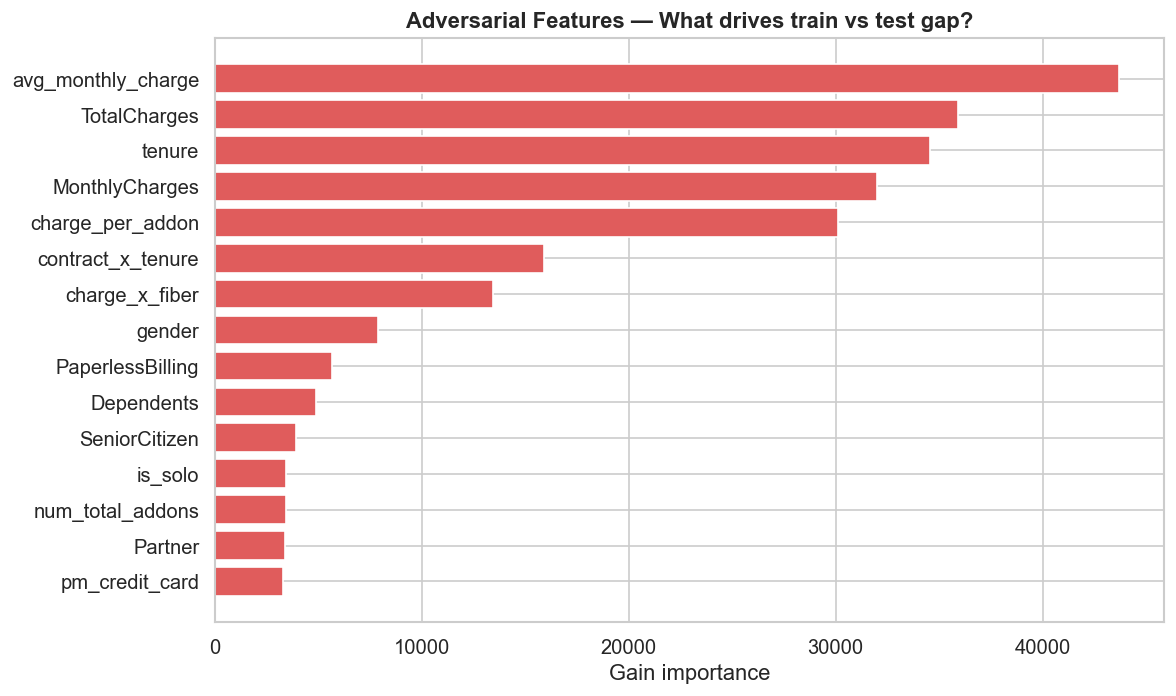

Top features driving train/test difference:
           feature         gain
avg_monthly_charge 43710.794665
      TotalCharges 35920.632807
            tenure 34551.141124
    MonthlyCharges 32003.950838
  charge_per_addon 30119.232777
 contract_x_tenure 15899.889162
    charge_x_fiber 13445.465617
            gender  7849.900957
  PaperlessBilling  5667.290545
        Dependents  4887.812399
     SeniorCitizen  3894.473754
           is_solo  3444.280102
  num_total_addons  3434.543912
           Partner  3381.158345
    pm_credit_card  3301.488855


In [3]:
# ── Which features drive the train/test gap? ──────────────────────────────
# Retrain on full adversarial dataset to get feature importances
adv_full = lgb.train(
    adv_params,
    lgb.Dataset(adv_X, label=adv_y),
    num_boost_round=2000,
    callbacks=[lgb.log_evaluation(0)]
)

adv_imp = pd.DataFrame({
    'feature'  : FEATURE_COLS,
    'gain'     : adv_full.feature_importance(importance_type='gain'),
}).sort_values('gain', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(adv_imp['feature'][::-1], adv_imp['gain'][::-1],
        color='#E05C5C', edgecolor='white')
ax.set_title('Adversarial Features — What drives train vs test gap?',
             fontweight='bold')
ax.set_xlabel('Gain importance')
plt.tight_layout()
plt.show()

print("Top features driving train/test difference:")
print(adv_imp.to_string(index=False))


---
## 3. Sample Weight Derivation

Convert adversarial probabilities into sample weights.
Formula: `weight = p / (1 - p)` where p = probability of being test-like.
Clipped to avoid extreme weights destabilising training.

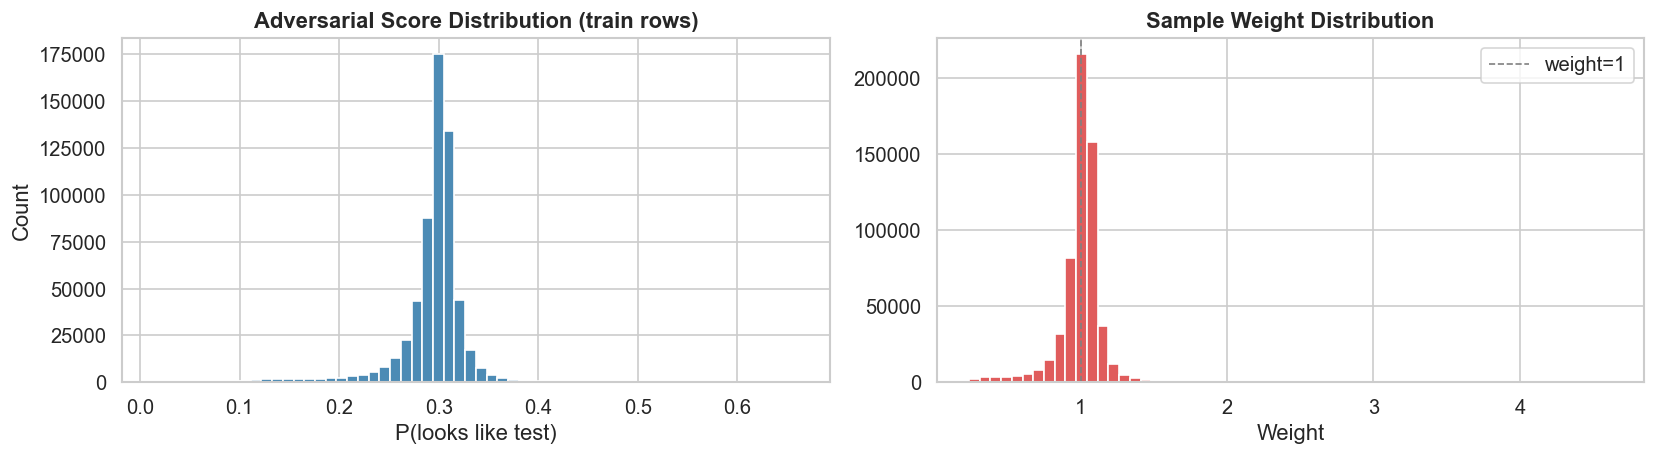

Weight stats:
  Mean   : 1.000
  Std    : 0.149
  Min    : 0.238
  Max    : 4.631
  % > 1  : 62.1%  (train rows boosted toward test)
  % < 1  : 37.9%  (train rows down-weighted)


In [4]:
# Recompute cleanly — retrain adversarial on full data, predict on train
adv_train_only = lgb.train(
    adv_params,
    lgb.Dataset(adv_X, label=adv_y),
    num_boost_round=2000,
    callbacks=[lgb.log_evaluation(0)]
)
p_test = adv_train_only.predict(X_train)  # prob each train row looks like test

# Weight = p / (1-p), clipped to [0.1, 10] to avoid extremes
weights = np.clip(p_test / (1 - p_test + 1e-6), 0.1, 10.0)

# Normalise so mean weight = 1 (doesn't change effective sample size)
weights = weights / weights.mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(p_test, bins=60, color='#4C8BB5', edgecolor='white')
axes[0].set_title('Adversarial Score Distribution (train rows)', fontweight='bold')
axes[0].set_xlabel('P(looks like test)')
axes[0].set_ylabel('Count')

axes[1].hist(weights, bins=60, color='#E05C5C', edgecolor='white')
axes[1].axvline(1.0, color='grey', linestyle='--', linewidth=1, label='weight=1')
axes[1].set_title('Sample Weight Distribution', fontweight='bold')
axes[1].set_xlabel('Weight')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Weight stats:")
print(f"  Mean   : {weights.mean():.3f}")
print(f"  Std    : {weights.std():.3f}")
print(f"  Min    : {weights.min():.3f}")
print(f"  Max    : {weights.max():.3f}")
print(f"  % > 1  : {(weights > 1).mean()*100:.1f}%  (train rows boosted toward test)")
print(f"  % < 1  : {(weights < 1).mean()*100:.1f}%  (train rows down-weighted)")


---
## 4. Baseline Weighted LightGBM

Same params as v3, with adversarial sample weights.
Reference: v3 OOF = 0.91627 unweighted.

In [5]:
def run_cv(params, X, y, w=None, n_rounds=1000, verbose=True):
    skf       = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    oof_preds = np.zeros(len(X))
    tst_preds = np.zeros(len(X_test))
    scores    = []
    gain_imp  = np.zeros(len(FEATURE_COLS))
    split_imp = np.zeros(len(FEATURE_COLS))

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
        w_tr = w[tr_idx] if w is not None else None

        dtrain = lgb.Dataset(X_tr, label=y_tr, weight=w_tr)
        dval   = lgb.Dataset(X_val, label=y_val)

        model = lgb.train(
            params, dtrain,
            num_boost_round=n_rounds,
            valid_sets=[dval],
            callbacks=[
                lgb.early_stopping(100, verbose=False),
                lgb.log_evaluation(period=100 if verbose else 0),
            ],
        )

        oof_preds[val_idx] = model.predict(X_val)
        tst_preds         += model.predict(X_test) / N_FOLDS
        gain_imp          += model.feature_importance('gain')  / N_FOLDS
        split_imp         += model.feature_importance('split') / N_FOLDS

        fold_auc = roc_auc_score(y_val, oof_preds[val_idx])
        scores.append(fold_auc)
        if verbose:
            print(f"  Fold {fold} — AUC: {fold_auc:.5f} | best iter: {model.best_iteration}")

    auc = roc_auc_score(y, oof_preds)
    if verbose:
        print(f"\n  OOF AUC : {auc:.5f}")
        print(f"  Mean    : {np.mean(scores):.5f} +/- {np.std(scores):.5f}")
    return oof_preds, tst_preds, scores, auc, gain_imp, split_imp


BASE_PARAMS = {
    'objective'        : 'binary',
    'metric'           : 'auc',
    'learning_rate'    : 0.05,
    'num_leaves'       : 31,
    'max_depth'        : 6,
    'min_child_samples': 50,
    'feature_fraction' : 0.8,
    'bagging_fraction' : 0.8,
    'bagging_freq'     : 5,
    'lambda_l1'        : 0.1,
    'lambda_l2'        : 1.0,
    'is_unbalance'     : True,
    'verbose'          : -1,
    'random_state'     : SEED,
}

print("=== WEIGHTED BASELINE ===")
oof_w, tst_w, scores_w, auc_w, _, _ = run_cv(
    BASE_PARAMS, X_train, y_train, w=weights
)
print(f"\n  vs v3 unweighted : {auc_w - 0.91627:+.5f}")


=== WEIGHTED BASELINE ===
[100]	valid_0's auc: 0.913652
[200]	valid_0's auc: 0.914948
[300]	valid_0's auc: 0.915289
[400]	valid_0's auc: 0.915554
[500]	valid_0's auc: 0.915664
[600]	valid_0's auc: 0.915771
[700]	valid_0's auc: 0.915831
[800]	valid_0's auc: 0.915877
  Fold 1 — AUC: 0.91588 | best iter: 774
[100]	valid_0's auc: 0.914779
[200]	valid_0's auc: 0.916047
[300]	valid_0's auc: 0.916452
[400]	valid_0's auc: 0.916609
[500]	valid_0's auc: 0.916743
[600]	valid_0's auc: 0.916848
[700]	valid_0's auc: 0.916867
[800]	valid_0's auc: 0.916898
[900]	valid_0's auc: 0.916911
  Fold 2 — AUC: 0.91692 | best iter: 876
[100]	valid_0's auc: 0.914167
[200]	valid_0's auc: 0.915352
[300]	valid_0's auc: 0.915776
[400]	valid_0's auc: 0.916026
[500]	valid_0's auc: 0.916149
[600]	valid_0's auc: 0.916224
[700]	valid_0's auc: 0.916236
[800]	valid_0's auc: 0.916295
  Fold 3 — AUC: 0.91630 | best iter: 784
[100]	valid_0's auc: 0.915288
[200]	valid_0's auc: 0.91658
[300]	valid_0's auc: 0.916946
[400]	valid_

---
## 5. Manual Param Tuning

Focused grid on the 4 params most likely to move the needle.
Each tested with adversarial weights, 5-fold CV.
Low CPU — testing one param at a time, others fixed at baseline.

In [11]:
results = []

# ── num_leaves ─────────────────────────────────────────────────────────────
print("Tuning num_leaves...")
for nl in [29, 31, 33]:
    p = {**BASE_PARAMS, 'num_leaves': nl}
    _, _, _, auc, _, _ = run_cv(p, X_train, y_train, w=weights, verbose=False)
    results.append({'param': 'num_leaves', 'value': nl, 'auc': auc})
    print(f"  num_leaves={nl:<4} → OOF AUC: {auc:.5f}")

# ── learning_rate ──────────────────────────────────────────────────────────
print("\nTuning learning_rate...")
for lr in [0.04, 0.05, 0.06]:
    p = {**BASE_PARAMS, 'learning_rate': lr}
    _, _, _, auc, _, _ = run_cv(p, X_train, y_train, w=weights, verbose=False)
    results.append({'param': 'learning_rate', 'value': lr, 'auc': auc})
    print(f"  learning_rate={lr:<5} → OOF AUC: {auc:.5f}")

# ── lambda_l2 ──────────────────────────────────────────────────────────────
print("\nTuning lambda_l2...")
for l2 in [10.0, 20.0, 50.0]:
    p = {**BASE_PARAMS, 'lambda_l2': l2}
    _, _, _, auc, _, _ = run_cv(p, X_train, y_train, w=weights, verbose=False)
    results.append({'param': 'lambda_l2', 'value': l2, 'auc': auc})
    print(f"  lambda_l2={l2:<5} → OOF AUC: {auc:.5f}")

# ── min_child_samples ──────────────────────────────────────────────────────
print("\nTuning min_child_samples...")
for mcs in [100]:
    p = {**BASE_PARAMS, 'min_child_samples': mcs}
    _, _, _, auc, _, _ = run_cv(p, X_train, y_train, w=weights, verbose=False)
    results.append({'param': 'min_child_samples', 'value': mcs, 'auc': auc})
    print(f"  min_child_samples={mcs:<4} → OOF AUC: {auc:.5f}")

results_df = pd.DataFrame(results)
print("\n=== TUNING SUMMARY ===")
print(results_df.sort_values('auc', ascending=False).to_string(index=False))

# Best value per param
print("\nBest value per param:")
for param in results_df['param'].unique():
    best = results_df[results_df['param']==param].sort_values('auc', ascending=False).iloc[0]
    print(f"  {param:<22}: {best['value']}  → AUC {best['auc']:.5f}")


Tuning num_leaves...
  num_leaves=29   → OOF AUC: 0.91627
  num_leaves=31   → OOF AUC: 0.91626
  num_leaves=33   → OOF AUC: 0.91623

Tuning learning_rate...
  learning_rate=0.04  → OOF AUC: 0.91629
  learning_rate=0.05  → OOF AUC: 0.91626
  learning_rate=0.06  → OOF AUC: 0.91620

Tuning lambda_l2...
  lambda_l2=10.0  → OOF AUC: 0.91634
  lambda_l2=20.0  → OOF AUC: 0.91636
  lambda_l2=50.0  → OOF AUC: 0.91639

Tuning min_child_samples...
  min_child_samples=100  → OOF AUC: 0.91628

=== TUNING SUMMARY ===
            param  value      auc
        lambda_l2  50.00 0.916386
        lambda_l2  20.00 0.916364
        lambda_l2  10.00 0.916343
    learning_rate   0.04 0.916285
min_child_samples 100.00 0.916281
       num_leaves  29.00 0.916274
       num_leaves  31.00 0.916256
    learning_rate   0.05 0.916256
       num_leaves  33.00 0.916230
    learning_rate   0.06 0.916199

Best value per param:
  num_leaves            : 29.0  → AUC 0.91627
  learning_rate         : 0.04  → AUC 0.91629
  

In [7]:
results = []

# ── lambda_l2 ──────────────────────────────────────────────────────────────
print("\nTuning lambda_l2...")
for l2 in [100.0, 150.0, 175.0]:
    p = {**BASE_PARAMS, 'lambda_l2': l2}
    _, _, _, auc, _, _ = run_cv(p, X_train, y_train, w=weights, verbose=False)
    results.append({'param': 'lambda_l2', 'value': l2, 'auc': auc})
    print(f"  lambda_l2={l2:<5} → OOF AUC: {auc:.5f}")


results_df = pd.DataFrame(results)
print("\n=== TUNING SUMMARY ===")
print(results_df.sort_values('auc', ascending=False).to_string(index=False))

# Best value per param
print("\nBest value per param:")
for param in results_df['param'].unique():
    best = results_df[results_df['param']==param].sort_values('auc', ascending=False).iloc[0]
    print(f"  {param:<22}: {best['value']}  → AUC {best['auc']:.5f}")



Tuning lambda_l2...
  lambda_l2=100.0 → OOF AUC: 0.91639
  lambda_l2=150.0 → OOF AUC: 0.91642
  lambda_l2=175.0 → OOF AUC: 0.91640

=== TUNING SUMMARY ===
    param  value      auc
lambda_l2  150.0 0.916415
lambda_l2  175.0 0.916403
lambda_l2  100.0 0.916386

Best value per param:
  lambda_l2             : 150.0  → AUC 0.91642


---
## 6. Final Model — Best Params + Weights

Update BEST_PARAMS below with the best value per param from section 5.

In [8]:
# ── Update these with best values from section 5 ─────────────────────────
BEST_PARAMS = {
    'objective'        : 'binary',
    'metric'           : 'auc',
    'learning_rate'    : 0.04,    # ← update
    'num_leaves'       : 29,      # ← update
    'max_depth'        : 6,
    'min_child_samples': 150,      # ← update
    'feature_fraction' : 0.8,
    'bagging_fraction' : 0.8,
    'bagging_freq'     : 5,
    'lambda_l1'        : 0.1,
    'lambda_l2'        : 50,     # ← update
    'is_unbalance'     : True,
    'verbose'          : -1,
    'random_state'     : SEED,
}

print("=== FINAL MODEL ===")
oof_final, tst_final, scores_final, auc_final, gain_imp, split_imp = run_cv(
    BEST_PARAMS, X_train, y_train, w=weights
)
print(f"\n  vs v3 unweighted    : {auc_final - 0.91627:+.5f}")
print(f"  vs weighted baseline: {auc_final - auc_w:+.5f}")


=== FINAL MODEL ===
[100]	valid_0's auc: 0.913032
[200]	valid_0's auc: 0.914529
[300]	valid_0's auc: 0.914991
[400]	valid_0's auc: 0.915403
[500]	valid_0's auc: 0.915588
[600]	valid_0's auc: 0.915732
[700]	valid_0's auc: 0.915825
[800]	valid_0's auc: 0.915855
[900]	valid_0's auc: 0.915862
[1000]	valid_0's auc: 0.915908
  Fold 1 — AUC: 0.91591 | best iter: 1000
[100]	valid_0's auc: 0.914105
[200]	valid_0's auc: 0.915638
[300]	valid_0's auc: 0.916216
[400]	valid_0's auc: 0.916454
[500]	valid_0's auc: 0.916664
[600]	valid_0's auc: 0.916809
[700]	valid_0's auc: 0.916906
[800]	valid_0's auc: 0.91698
[900]	valid_0's auc: 0.917047
[1000]	valid_0's auc: 0.917073
  Fold 2 — AUC: 0.91707 | best iter: 1000
[100]	valid_0's auc: 0.913568
[200]	valid_0's auc: 0.914984
[300]	valid_0's auc: 0.915498
[400]	valid_0's auc: 0.915909
[500]	valid_0's auc: 0.916134
[600]	valid_0's auc: 0.916225
[700]	valid_0's auc: 0.916344
[800]	valid_0's auc: 0.916428
[900]	valid_0's auc: 0.916434
[1000]	valid_0's auc: 0.9

---
## 7. OOF Analysis

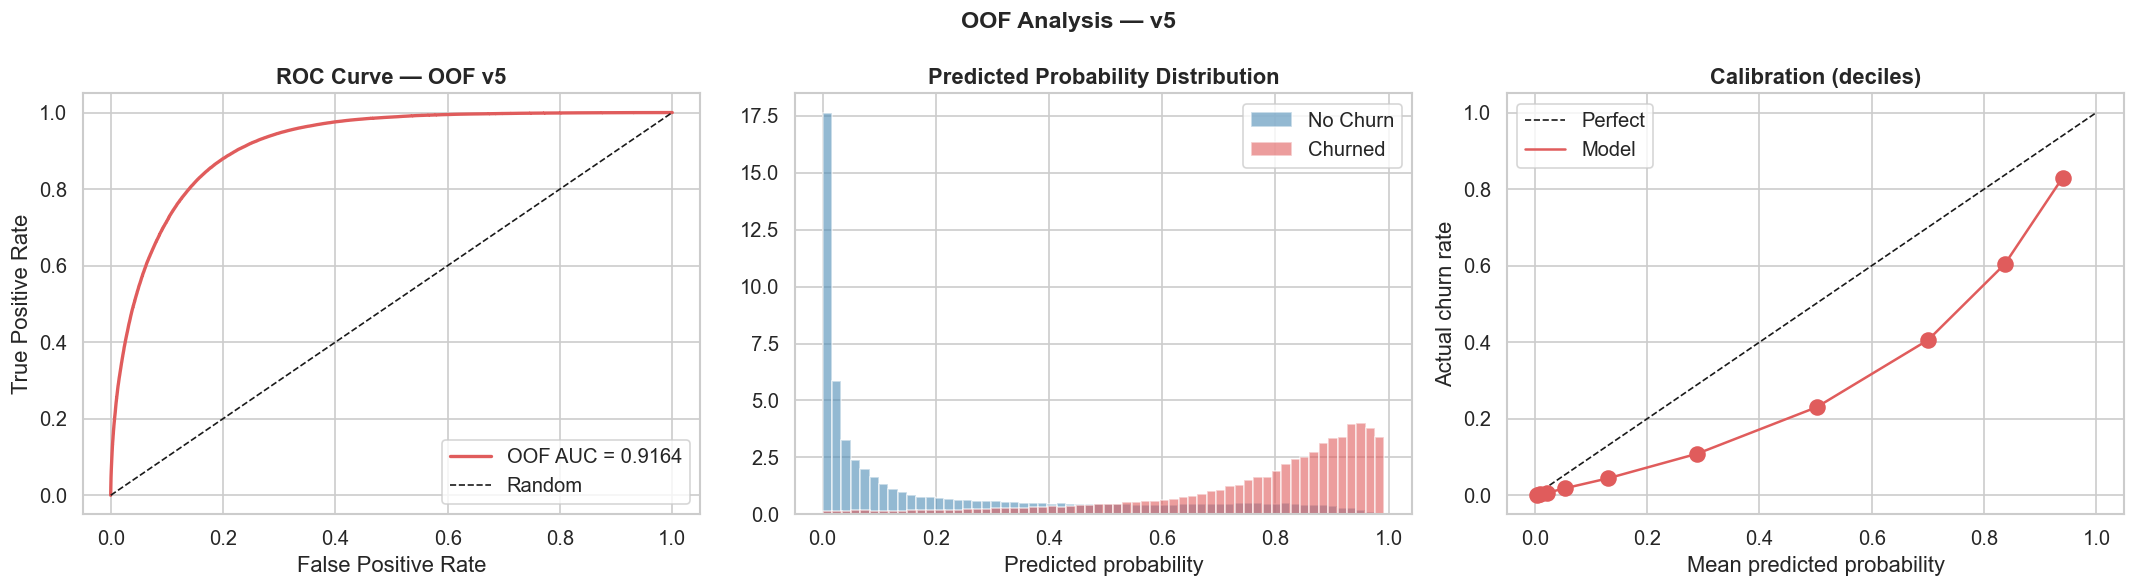

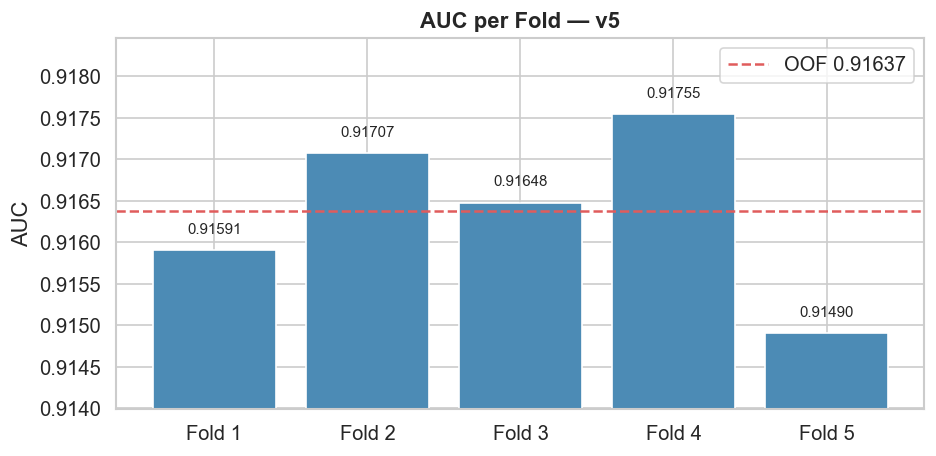

In [9]:
fpr, tpr, _ = roc_curve(y_train, oof_final)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(fpr, tpr, color='#E05C5C', linewidth=2,
             label=f'OOF AUC = {auc_final:.4f}')
axes[0].plot([0,1],[0,1], 'k--', linewidth=1, label='Random')
axes[0].set_title('ROC Curve — OOF v5', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

axes[1].hist(oof_final[y_train==0], bins=60, alpha=0.6,
             color='#4C8BB5', label='No Churn', density=True)
axes[1].hist(oof_final[y_train==1], bins=60, alpha=0.6,
             color='#E05C5C', label='Churned', density=True)
axes[1].set_title('Predicted Probability Distribution', fontweight='bold')
axes[1].set_xlabel('Predicted probability')
axes[1].legend()

oof_df = pd.DataFrame({'prob': oof_final, 'actual': y_train})
oof_df['decile'] = pd.qcut(oof_df['prob'], q=10, labels=False)
calib = oof_df.groupby('decile').agg(
    mean_pred=('prob','mean'), actual_rate=('actual','mean')
).reset_index()
axes[2].plot([0,1],[0,1],'k--',linewidth=1,label='Perfect')
axes[2].scatter(calib['mean_pred'], calib['actual_rate'],
                color='#E05C5C', s=80, zorder=5)
axes[2].plot(calib['mean_pred'], calib['actual_rate'],
             color='#E05C5C', linewidth=1.5, label='Model')
axes[2].set_title('Calibration (deciles)', fontweight='bold')
axes[2].set_xlabel('Mean predicted probability')
axes[2].set_ylabel('Actual churn rate')
axes[2].legend()

plt.suptitle('OOF Analysis — v5', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar([f'Fold {i}' for i in range(1, N_FOLDS+1)], scores_final,
              color='#4C8BB5', edgecolor='white')
for bar, val in zip(bars, scores_final):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.0002,
            f'{val:.5f}', ha='center', fontsize=9)
ax.axhline(auc_final, color='#E05C5C', linestyle='--',
           linewidth=1.5, label=f'OOF {auc_final:.5f}')
ax.set_title('AUC per Fold — v5', fontweight='bold')
ax.set_ylabel('AUC')
ax.set_ylim(min(scores_final)*0.999, max(scores_final)*1.001)
ax.legend()
plt.tight_layout()
plt.show()


---
## 8. Feature Importance

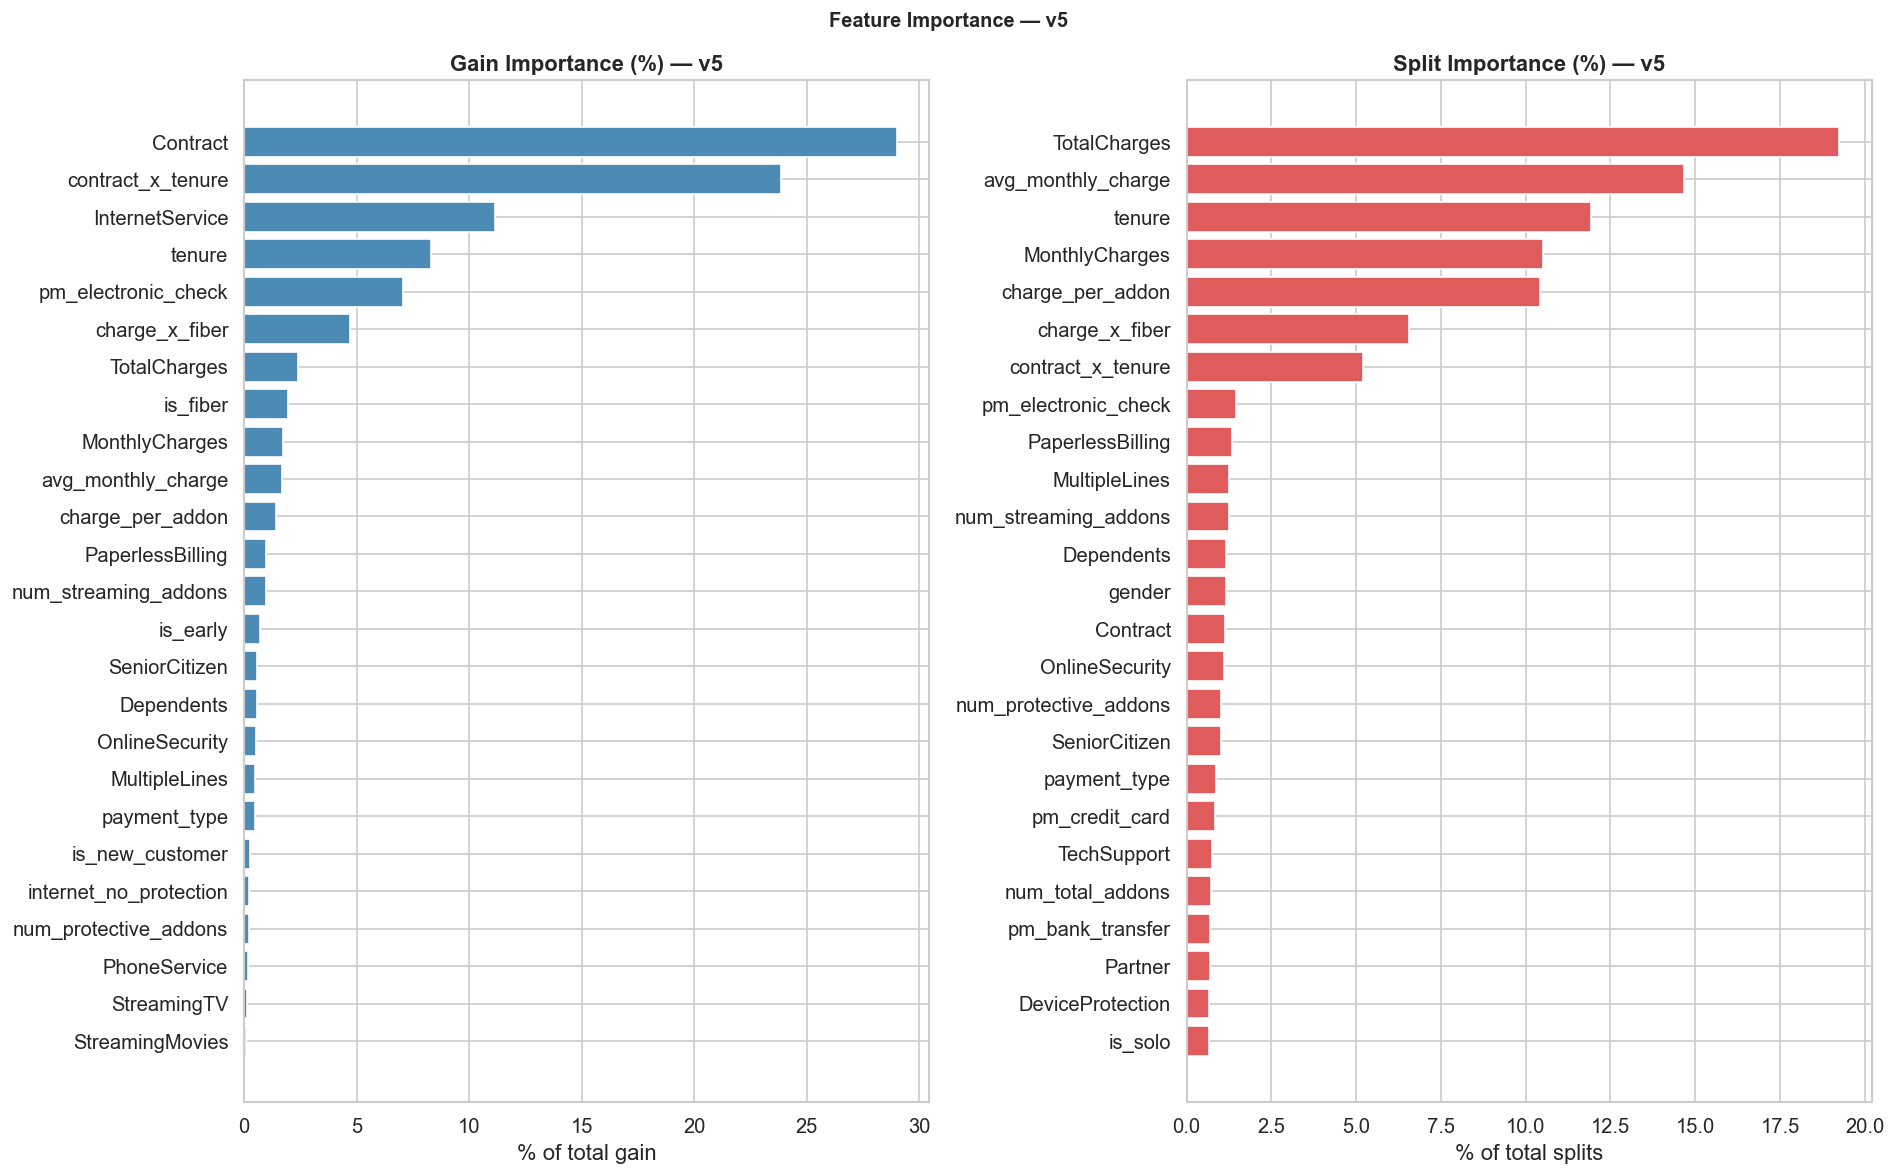

             feature  gain_norm  split_norm
            Contract      28.99        1.12
   contract_x_tenure      23.85        5.19
     InternetService      11.14        0.41
              tenure       8.28       11.92
 pm_electronic_check       7.04        1.46
      charge_x_fiber       4.72        6.56
        TotalCharges       2.39       19.24
            is_fiber       1.95        0.04
      MonthlyCharges       1.72       10.52
  avg_monthly_charge       1.70       14.66
    charge_per_addon       1.40       10.43
    PaperlessBilling       0.97        1.35
num_streaming_addons       0.96        1.25
            is_early       0.70        0.15
       SeniorCitizen       0.58        1.01
          Dependents       0.56        1.16
      OnlineSecurity       0.53        1.10
       MultipleLines       0.50        1.26
        payment_type       0.49        0.87
     is_new_customer       0.24        0.13


In [10]:
imp_df = pd.DataFrame({
    'feature'   : FEATURE_COLS,
    'gain_norm' : (gain_imp  / gain_imp.sum()  * 100).round(2),
    'split_norm': (split_imp / split_imp.sum() * 100).round(2),
}).sort_values('gain_norm', ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 10))
axes[0].barh(imp_df['feature'][:25][::-1], imp_df['gain_norm'][:25][::-1],
             color='#4C8BB5', edgecolor='white')
axes[0].set_title('Gain Importance (%) — v5', fontweight='bold')
axes[0].set_xlabel('% of total gain')

top_split = imp_df.sort_values('split_norm', ascending=False).head(25)
axes[1].barh(top_split['feature'][::-1], top_split['split_norm'][::-1],
             color='#E05C5C', edgecolor='white')
axes[1].set_title('Split Importance (%) — v5', fontweight='bold')
axes[1].set_xlabel('% of total splits')

plt.suptitle('Feature Importance — v5', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(imp_df[['feature','gain_norm','split_norm']].head(20).to_string(index=False))


---
## 9. Submission

Sanity checks: ✅
Rows      : 254,655
Churn mean: 0.3414  (train: 0.2252)

Version comparison (OOF):
  v1 — 41 + risk_score, no weights : 0.91622  | LB: 0.91398
  v3 — 40, no risk_score, no weights: 0.91627  | LB: 0.91398
  v5 — 40, no risk_score, weighted  : 0.91637  | LB: pending


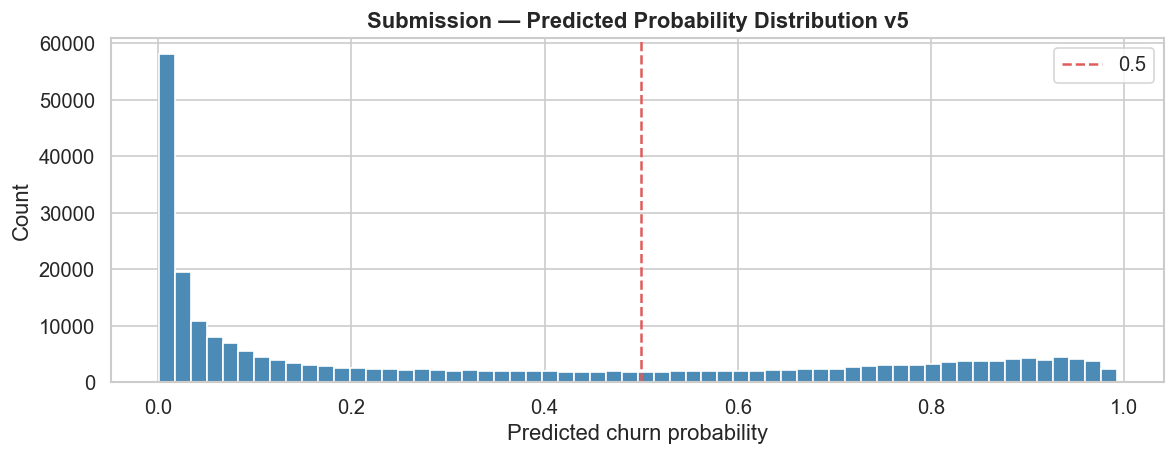


✅ Saved: /Users/clairedebadts/kaggle/customer-churn/submissionv5ter.csv


In [11]:
import os

submission = pd.DataFrame({
    'id'   : test_ids['id'],
    'Churn': tst_final
})

assert submission['id'].nunique() == len(submission)
assert submission['Churn'].between(0, 1).all()
assert submission.isnull().sum().sum() == 0
print("Sanity checks: ✅")
print(f"Rows      : {len(submission):,}")
print(f"Churn mean: {submission['Churn'].mean():.4f}  (train: {y_train.mean():.4f})")
print(f"\nVersion comparison (OOF):")
print(f"  v1 — 41 + risk_score, no weights : 0.91622  | LB: 0.91398")
print(f"  v3 — 40, no risk_score, no weights: 0.91627  | LB: 0.91398")
print(f"  v5 — 40, no risk_score, weighted  : {auc_final:.5f}  | LB: pending")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(submission['Churn'], bins=60, color='#4C8BB5', edgecolor='white')
ax.axvline(0.5, color='#E05C5C', linestyle='--', linewidth=1.5, label='0.5')
ax.set_title('Submission — Predicted Probability Distribution v5', fontweight='bold')
ax.set_xlabel('Predicted churn probability')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

os.makedirs(OUT_DIR, exist_ok=True)
submission.to_csv(OUT_DIR + "submissionv5ter.csv", index=False)
print(f"\n✅ Saved: {OUT_DIR}submissionv5ter.csv")
